# Load, Subset, and Reproject NISAR GCOV Data with `ISCE3`
<br>

This notebook demonstrates how to load GCOV data with [`ISCE3`](https://github.com/isce-framework/isce3)'s NISAR Product Reader.

<hr>

## Overview

1. [Prerequisites](isce3-prereqs)
2. [Search and download a GCOV product](isce3-search-download)
1. [Load an HDF5 dataset as a `GenericProduct.GCOV` object](isce3-load)
1. [View the `GCOV` metadata](isce3-metadata)
1. [Load a backscatter or covariance image dataset](isce3-image)
1. [Subset the data by index](isce3-subset)
1. [Reproject the data](isce3-reproject)
1. [Calculate statistics and transformations on the data](isce3-stats)
1. [Plot the data](isce3-lot)
1. [Summary](isce3-summary)
1. [Resources and references](isce3-resources)

<hr>

(isce3-prereqs)=
## 1. Prerequisites
| Prerequisite | Importance | Notes |
| --- | --- | --- |
| [The software environment for this cookbook must be installed](https://github.com/ASFOpenSARlab/NISAR_GCOV_Cookbook/blob/main/notebooks/create_software_environment.ipynb) | Necessary | |

- **Rough Notebook Time Estimate**: 3 minutes

<hr>

(isce3-search-download)=
## 2. Search and download a GCOV product

### 2a. Search for GCOV data with asf_search

In [1]:
import os
import asf_search as asf
from datetime import datetime
from getpass import getpass

session = asf.ASFSession()
session.auth_with_creds(input('EDL Username'), getpass('EDL Password'))

start_date = datetime(2025, 11, 22)
end_date = datetime(2025, 12, 5)
area_of_interest = "POLYGON((40.9131 12.3904,41.8891 12.3904,41.8891 13.2454,40.9131 13.2454,40.9131 12.3904))" # POINT or POLYGON as WKT (well-known-text)

opts=asf.ASFSearchOptions(**{
    "maxResults": 250,
    "intersectsWith": area_of_interest,
    "start": start_date,
    "end": end_date,
    "processingLevel": [
        "GCOV"
    ],
    "dataset": [
        "NISAR"
    ],
    "productionConfiguration": [
        "PR"
    ],
    "dataMaturity" : "PROVISIONAL",
    'session': session,
})

response = asf.search(opts=opts)
pattern = r'^(?!.*QA_STATS).*'
hdf5_files = response.find_urls(extension='.h5', pattern=pattern, directAccess=False)
hdf5_files

EDL Username aflewandowski
EDL Password ········


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_P05023_N_F_J_001/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_006_165_D_082_2005_SHSH_A_20251203T154910_20251203T154945_P05023_N_F_J_001/NISAR_L2_PR_GCOV_006_165_D_082_2005_SHSH_A_20251203T154910_20251203T154945_P05023_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_P05023_N_F_J_001/NISAR_L2_PR_GCOV_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_P05023_N_F_J_001.h5']

### 2b. Download a GCOV product

In [2]:
from pathlib import Path

data_dir = Path.home() / "load_subset_reproject_isce3_GCOV_data"
data_dir.mkdir(exist_ok=True)
print(f'data_dir: {data_dir}')

asf.download_url(hdf5_files[0], data_dir, session=session)

data_dir: /home/jovyan/load_subset_reproject_isce3_GCOV_data


<hr>

(isce3-load)=
## 3. Load an HDF5 dataset as a `GenericProduct.GCOV` object

In [3]:
from nisar.products.readers import open_product
from pathlib import Path

data_dir = Path.home() / "GCOV_data"
data_dir.mkdir(exist_ok=True)
gcov_path = list(data_dir.glob("*.h5"))[0]
gcov = open_product(gcov_path) 
gcov

<hr>

(isce3-metadata)=
## 4. View the `GCOV` metadata
 
**The `GCOV` object contains member variables, methods, and additional `ISCE3` objects that all hold product metadata.**

### 4a. View the available `GCOV` member variables.

In [4]:
gcov_member_variables = {
    "CFPath": gcov.CFPath,
    "CalibrationInformationPath": gcov.CalibrationInformationPath,
    "GridPath": gcov.GridPath,
    "IdentificationPath": gcov.IdentificationPath,
    "MetadataPath": gcov.MetadataPath,
    "ProcessingInformationPath": gcov.ProcessingInformationPath,
    "ProductPath": gcov.ProductPath,
    "RootPath": gcov.RootPath,
    "SwathPath": gcov.SwathPath,
    "covarianceTerms": gcov.covarianceTerms,
    "error_channel": gcov.error_channel,
    "filename": gcov.filename,
    "frequencies": gcov.frequencies,
    "identification": gcov.identification,
    "polarizations": gcov.polarizations,
    "productType": gcov.productType,
    "productValidationType": gcov.productValidationType,
    "sarBand": gcov.sarBand,
    "sourceDataPath": gcov.sourceDataPath,
    "sourceDataProcessingInfoPath": gcov.sourceDataProcessingInfoPath,
    "sourceDataSwathsPath": gcov.sourceDataSwathsPath
}
max_len = max(len(v) for v in sorted(gcov_member_variables.keys()))
for k, v in gcov_member_variables.items():
    print(f"{k:{max_len}} {v}")

CFPath                       /
CalibrationInformationPath   /science/LSAR/GCOV/metadata/calibrationInformation
GridPath                     /science/LSAR/GCOV/grids
IdentificationPath           /science/LSAR/identification
MetadataPath                 /science/LSAR/GCOV/metadata
ProcessingInformationPath    /science/LSAR/GCOV/metadata/processingInformation
ProductPath                  /science/LSAR/GCOV
RootPath                     /science/LSAR
SwathPath                    /science/LSAR/GCOV/swaths
covarianceTerms              {'A': ['HHHH'], 'B': ['HHHH']}
error_channel                <journal.ext.journal.Error object at 0x7ff83929d630>
filename                     /home/jovyan/GCOV_data/NISAR_L2_PR_GCOV_006_165_D_082_2005_SHSH_A_20251203T154910_20251203T154945_P05023_N_F_J_001.h5
frequencies                  ['A', 'B']
identification               <nisar.products.readers.Base.Identification.Identification object at 0x7ff8392beba0>
polarizations                {'A': ['HH'], 'B': ['HH

### 4b. View the `GCOV` get metadata methods

In [5]:
gcov_metadata_functions = {
    'getCenterFrequency("B")': gcov.getCenterFrequency("B"),
    'getProjectionEpsg()': gcov.getProjectionEpsg(),
    'getGeoGridCoordinateSpacing()': gcov.getGeoGridCoordinateSpacing(),
    'getProductLevel()': gcov.getProductLevel(),
    'getWavelength("B")': gcov.getWavelength("B"),
    
}
max_len = max(len(v) for v in sorted(gcov_metadata_functions.keys()))
for k, v in gcov_metadata_functions.items():
    print(f"{k:{max_len}} {v}")    

getCenterFrequency("B")       1293500000.0
getProjectionEpsg()           32637
getGeoGridCoordinateSpacing() (np.float64(20.0), np.float64(-20.0))
getProductLevel()             L2
getWavelength("B")            0.23176842520293778


### 4c. View the metadata contained in the `GCOV.Identification` object

In [6]:

gcov_identification_member_variables = {
    "absoluteOrbitNumber": gcov.identification.absoluteOrbitNumber,
    "boundingPolygon": gcov.identification.boundingPolygon,
    "diagnosticModeFlag": gcov.identification.diagnosticModeFlag,
    "diagnosticModeName": gcov.identification.diagnosticModeName,
    "isJointObservation": gcov.identification.isJointObservation,
    "isUrgentObservation": gcov.identification.isUrgentObservation,
    "listOfFrequencies": gcov.identification.listOfFrequencies,
    "lookDirection": gcov.identification.lookDirection,
    "missionId": gcov.identification.missionId,
    "orbitPassDirection": gcov.identification.orbitPassDirection,
    "plannedDatatake": gcov.identification.plannedDatatake,
    "plannedObservation": gcov.identification.plannedObservation,
    "productType": gcov.identification.productType,
    "zdEndTime": gcov.identification.zdEndTime,
    "zdStartTime": gcov.identification.zdStartTime
}
max_len = max(len(v) for v in sorted(gcov_identification_member_variables.keys()))
for k, v in gcov_identification_member_variables.items():
    print(f"{k:{max_len}} {v}")    

absoluteOrbitNumber 1821
boundingPolygon     POLYGON ((39.3607818607813 14.248319051321 2366.32299804807,39.3022440954932 14.0353996252947 1920.51611328076,39.2528727594568 13.8203543335465 2146.03141875786,39.2031781674395 13.605400060416 2339.21289062466,39.1510502548509 13.3910285664428 2342.67673431043,39.0903509117753 13.1786665059479 1699.29797253048,39.0418556430526 12.9634771118623 1955.34949191018,38.9895649839527 12.7491856297675 1920.54272460449,38.9405065461852 12.5341567304984 2118.45117163637,38.8899058799918 12.3195011819149 2193.1989746094,38.8355231204151 12.1057371844582 1977.051881154,39.105042126914 12.0430481535428 2839.22933084966,39.351219285236 11.9855337470481 2743.70166015741,39.585353974324 11.9306086896252 2364.19360351464,39.8070861634776 11.8783919458353 1500.87622070886,40.0259085004577 11.8266703393676 929.145080566761,40.2435419724795 11.7750433320617 792.59588622948,40.4580225311253 11.7239827171872 868.341917433096,40.6659195655971 11.6743173346755 73

### 4d. Get the `GCOV` `Orbit` object

In [7]:
orbit = gcov.getOrbit()
orbit

#### View the `Orbit` object member variables

In [8]:
orbit_member_variables = {
    "end_datetime": orbit.end_datetime,
    "end_time": orbit.end_time,
    "mid_datetime": orbit.mid_datetime,
    "mid_time": orbit.mid_time,
    "position": orbit.position,
    "reference_epoch": orbit.reference_epoch,
    "size": orbit.size,
    "spacing": orbit.spacing,
    "start_datetime": orbit.start_datetime,
    "start_time": orbit.start_time,
    "position": orbit.position,
    "velocity": orbit.velocity,
}
max_len = max(len(v) for v in sorted(orbit_member_variables.keys()))
for k, v in orbit_member_variables.items():
    print(f"{k:{max_len}} {v}")    

end_datetime    2025-12-03T15:55:52.000000000
end_time        57352.0
mid_datetime    2025-12-03T15:50:37.000000000
mid_time        57037.0
position        [[ 4885216.26875639  3911006.72558519  3410248.61705241]
 [ 4923211.17916032  3919601.00076722  3345342.60234317]
 [ 4960678.85544267  3927710.78278835  3280067.31606917]
 [ 4997614.47941606  3935335.95070901  3214429.95963688]
 [ 5034013.29133197  3942476.44425238  3148437.77469761]
 [ 5069870.59072318  3949132.26330761  3082098.04253884]
 [ 5105181.73683138  3955303.46797949  3015418.08343474]
 [ 5139942.14940027  3960990.17849148  2948405.25555823]
 [ 5174147.30905064  3966192.57530004  2881066.95426169]
 [ 5207792.75813731  3970910.89872574  2813410.61116741]
 [ 5240874.10114132  3975145.44887254  2745443.69366994]
 [ 5273387.00536366  3978896.58580033  2677173.70346911]
 [ 5305327.20139287  3982164.72933789  2608608.17601528]
 [ 5336690.48384145  3984950.3586599   2539754.67978153]
 [ 5367472.71171614  3987254.01242358  2470620

#### View the `Orbit` object methods

In [9]:
orbit_methods = {
    "get_type": orbit.get_type(),
    "get_interp_method": orbit.get_interp_method(),
}
max_len = max(len(v) for v in sorted(orbit_methods.keys()))
for k, v in orbit_methods.items():
    print(f"{k:{max_len}} {v}")

get_type          MOE
get_interp_method OrbitInterpMethod.HERMITE


### 4e. Get the `GCOV`'s `RadarGridParameters` object

In [10]:
radar_grid_param = gcov.getSourceRadarGridParameters("B")
radar_grid_param

#### View the `RadarGridParameters` object's member variables

In [11]:
radar_grid_params = {
    "az_time_interval": radar_grid_param.az_time_interval,
    "end_range": radar_grid_param.end_range,
    "length": radar_grid_param.length,
    "lookside": radar_grid_param.lookside,
    "mid_range": radar_grid_param.mid_range,
    "prf": radar_grid_param.prf,
    "range_pixel_spacing": radar_grid_param.range_pixel_spacing,
    "ref_epoch": radar_grid_param.ref_epoch,
    "sensing_datetime()": radar_grid_param.sensing_datetime(),
    "sensing_mid": radar_grid_param.sensing_mid,
    "sensing_start": radar_grid_param.sensing_start,
    "sensing_stop": radar_grid_param.sensing_stop,
    "shape": radar_grid_param.shape,
    "size": radar_grid_param.size,
    "starting_range": radar_grid_param.starting_range,
    "wavelength": radar_grid_param.wavelength,
    "width": radar_grid_param.width,
}
max_len = max(len(v) for v in sorted(radar_grid_params.keys()))
for k, v in radar_grid_params.items():
    print(f"{k:{max_len}} {v}")    

az_time_interval    0.0006578947368421052
end_range           1046725.367107
length              54720
lookside            LookSide.Left
mid_range           964444.8287384167
prf                 1520.0
range_pixel_spacing 24.982704833333333
ref_epoch           2025-12-03T00:00:00.000000000
sensing_datetime()  2025-12-03T15:49:10.000000000
sensing_mid         56967.99967105263
sensing_start       56950.0
sensing_stop        56985.999342105264
shape               (54720, 6588)
size                360495360
starting_range      882164.2903698334
wavelength          0.23176842520293778
width               6588


### 4f. Get the `GCOV`'s  `GeoGridParameters` object

In [12]:
geo_grid_param = gcov.getGeoGridParameters("B", "HHHH")
geo_grid_param

#### View the `GeoGridParameters` object's member variables

In [13]:
geo_grid_params = {
    "end_y": geo_grid_param.end_y,
    "end_x": geo_grid_param.end_x,
    "epsg":geo_grid_param.epsg,
    "length": geo_grid_param.length,
    "spacing_x": geo_grid_param.spacing_x,
    "spacing_y": geo_grid_param.spacing_y,
    "start_x": geo_grid_param.start_x,
    "start_y": geo_grid_param.start_y,
    "width": geo_grid_param.width
}
max_len = max(len(v) for v in sorted(geo_grid_params.keys()))
for k, v in geo_grid_params.items():
    print(f"{k:{max_len}} {v}")   

end_y     1254240.0
end_x     804240.0
epsg      32637
length    4140
spacing_x 80.0
spacing_y -80.0
start_x   465840.0
start_y   1585440.0
width     4230


<hr>

(isce3-image)=
## 5. Load a backscatter or covariance image dataset

In [14]:
hh_backscatter_power = gcov.getImageDataset(frequency='B', polarization='HHHH')
hh_backscatter_power

<HDF5 dataset "HHHH": shape (4140, 4230), type "<f4">

<hr>

(isce3-subset)=
## 6. Subset the data by index

In [15]:
hh_subset = hh_backscatter_power[2000:2500, 2000:2500]
print(f"hh_subset.shape: {hh_subset.shape}")
hh_subset

hh_subset.shape: (500, 500)


array([[0.0602355 , 0.05916023, 0.05186033, ..., 0.12300777, 0.12761307,
        0.16632271],
       [0.06679344, 0.07860661, 0.0487752 , ..., 0.18728447, 0.19374847,
        0.17194939],
       [0.03771687, 0.04844141, 0.07712841, ..., 0.21936798, 0.1552391 ,
        0.20528793],
       ...,
       [0.10801315, 0.10937691, 0.07564354, ..., 0.12128353, 0.13926125,
        0.19968987],
       [0.09237671, 0.07653236, 0.07016945, ..., 0.2156372 , 0.21333504,
        0.19182587],
       [0.08720207, 0.0366807 , 0.07624817, ..., 0.1162014 , 0.18413925,
        0.2521057 ]], shape=(500, 500), dtype=float32)

<hr>

(isce3-reproject)=
## 7. Reproject the data

There are multiple ways to reproject the data. `GCOV` objects do not have a reprogection method, so you will need to use other tools. This example uses `xarray` and `rioxarray`.

In [16]:
import xarray as xr
import rioxarray

# Load the image layer in an xarray.DataArray
da = xr.DataArray(
    hh_backscatter_power[...],
    dims=("y", "x"),
    name="HHHH",
)

# Add spatial coords to the DataArray
x_coords, y_coords = gcov.getGeoGridCoordinateDatasets("B")
da = da.assign_coords(y=("y", y_coords), x=("x", x_coords))

# Add the current CRS to the DataArray
epsg = gcov.getProjectionEpsg()
da = da.rio.write_crs(f"EPSG:{epsg}", inplace=True)

# Set the y and x coords as spatial dimensions
da = da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)

# reproject the data
da_reproj = da.rio.reproject("EPSG:4326", inplace=True)
hh_reproj_subset = da_reproj[2000:2500, 2000:2500]
hh_reproj_subset

<xarray.DataArray 'HHHH' (y: 500, x: 500)> Size: 1MB
array([[0.0712347 , 0.06684208, 0.04551554, ..., 0.10963154, 0.13465881,
        0.08717346],
       [0.03038669, 0.03548336, 0.03376818, ..., 0.11567974, 0.10294533,
        0.12772942],
       [0.04851532, 0.03708029, 0.06712341, ..., 0.10907078, 0.13659859,
        0.13654137],
       ...,
       [0.0741806 , 0.11711025, 0.09753418, ..., 0.17793274, 0.13292313,
        0.18118858],
       [0.10824394, 0.10718346, 0.10301781, ..., 0.1579094 , 0.2001915 ,
        0.20897293],
       [0.07571983, 0.0830698 , 0.08447266, ..., 0.17727661, 0.16757011,
        0.16251373]], shape=(500, 500), dtype=float32)
Coordinates:
  * y            (y) float64 4kB 12.88 12.88 12.88 12.88 ... 12.52 12.52 12.52
  * x            (x) float64 4kB 40.14 40.14 40.15 40.15 ... 40.51 40.51 40.51
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

In [17]:
hh_reproj_subset.spatial_ref.attrs

{'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]',
 'semi_major_axis': 6378137.0,
 'semi_minor_axis': 6356752.314245179,
 'inverse_flattening': 298.257223563,
 'reference_ellipsoid_name': 'WGS 84',
 'longitude_of_prime_meridian': 0.0,
 'prime_meridian_name': 'Greenwich',
 'geographic_crs_name': 'WGS 84',
 'horizontal_datum_name': 'World Geodetic System 1984',
 'grid_mapping_name': 'latitude_longitude',
 'spatial_ref': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]',
 'Geo

<hr>

(isce3-stats)=
## 7. Calculate statistics and transformations on the data

### As a loaded HDF5 dataset, you can call many `numpy` functions directly on the data.

In [18]:
import numpy as np

print(f"min: {np.nanmin(hh_backscatter_power)}")
print(f"max: {np.nanmax(hh_backscatter_power)}")
print(f"mean: {np.nanmean(hh_backscatter_power)}")

min: 8.144560601029e-17
max: 142.82421875
mean: 0.15281380712985992


### Note that some `numpy` functions and attributes are not available with the loaded HDF5 dataset

For example, the code cell below will raise an `AttributeError` when trying to view the `T` (transpose attribute)

In [19]:
hh_backscatter_power.T

AttributeError: 'Dataset' object has no attribute 'T'

### To view the `T` attribute, you must first read the data into memory as a `numpy.ndarray`

You can trigger the data to be read into memory by indexing the entire dataset with `[...]`:

`hh_backscatter_power.T` -> `hh_backscatter_power[...].T`

In [ ]:
print(f"hh_backscatter_power.shape: {hh_backscatter_power.shape}")
print(f"hh_backscatter_power[...].T.shape: {hh_backscatter_power[...].T.shape}\n")

hh_backscatter_power[...].T

<hr>

(isce3-plot)=
## 8. Plot the data

### Convert the data from linear scale (power) to logarithmic scale (dB) for visualization

In [20]:
hh_backscatter_dB = 10 * np.log10(hh_backscatter_power)

### Plot the image data in dB

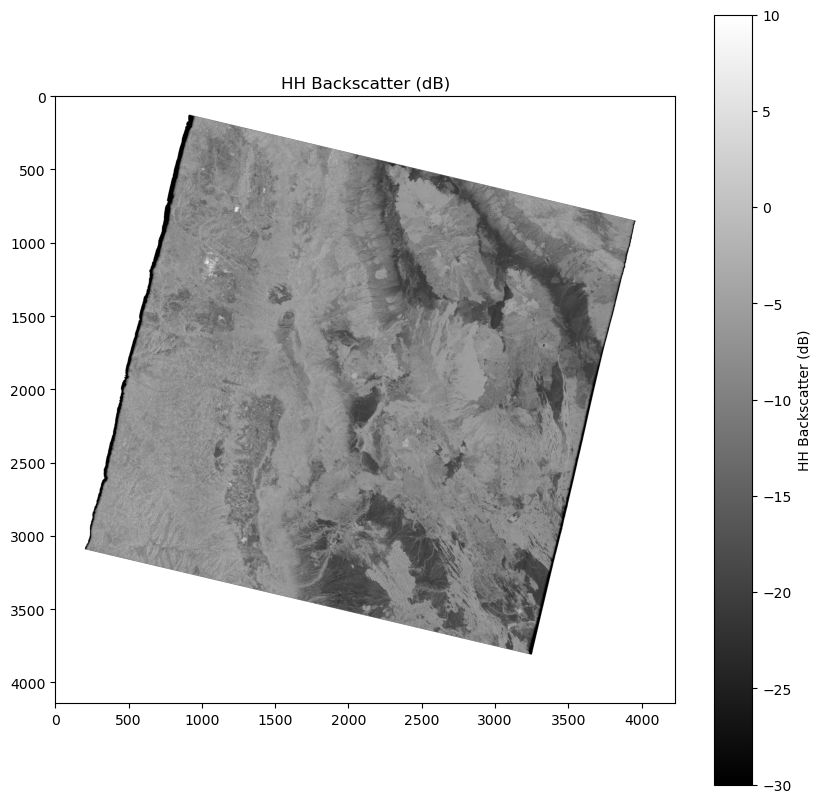

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(hh_backscatter_dB, cmap="gray", vmin=-30.0, vmax=10.0)
plt.colorbar(label="HH Backscatter (dB)")
plt.title("HH Backscatter (dB)")
plt.show()

<hr>

(isce3-summary)=
## 4. Summary

You have now run an example that loads NISAR GCOV data with `isce3`, accesses its metadata, creates a subset, reprojects the data, and plots an image layer.
<hr>

(isce3-resources)=
## 6. Resources and references
- [isce3](https://github.com/isce-framework/isce3)

**Author:** Alex Lewandowski